Fragments processed: 360
  unaffected: 172
  trimmed:    135
  dropped:    53
Total residues removed: 5807
Plots written to ../PLOTS/


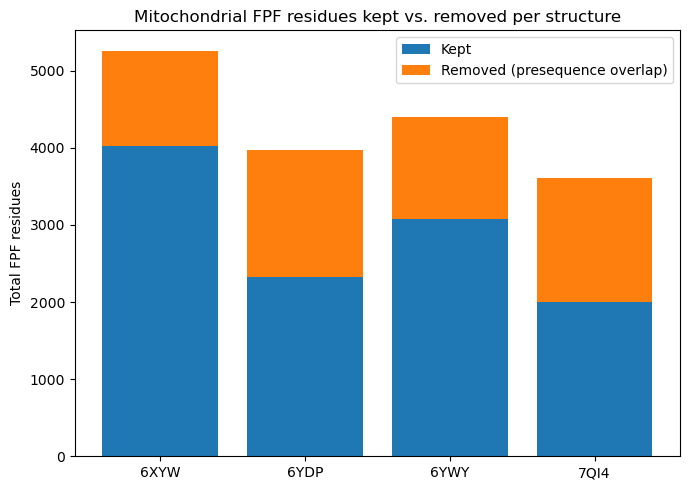

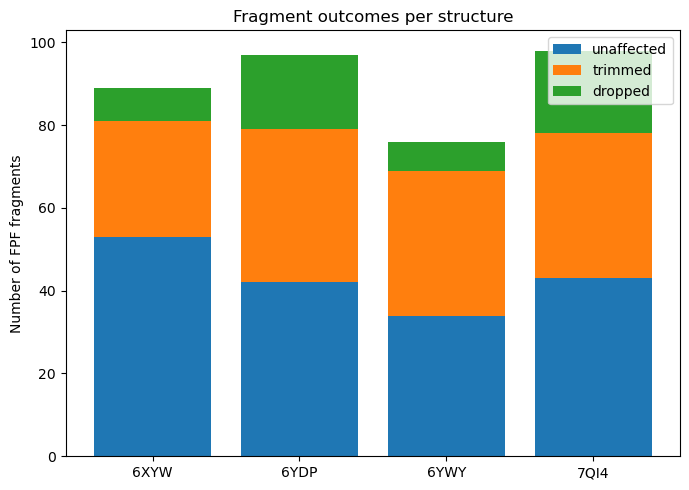

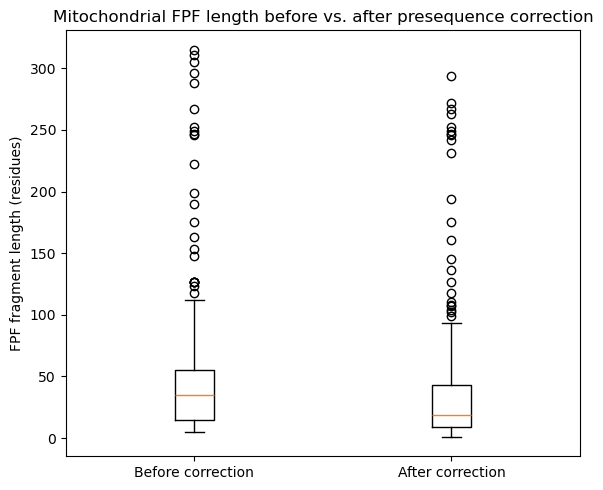

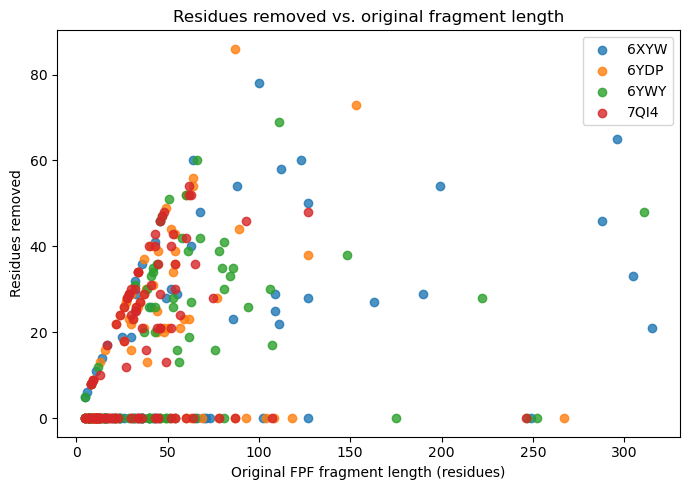

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

BASE_DIR = Path("..")
PLOTS_DIR = BASE_DIR / "PLOTS"
PLOTS_DIR.mkdir(exist_ok=True)

with open(BASE_DIR / "fpf_info_full.json") as f:
    fpf_info_full = json.load(f)

with open(BASE_DIR / "fpf_info_presequence_corrected.json") as f:
    fpf_info_corrected = json.load(f)

with open(BASE_DIR / "ribosome_info.json") as f:
    ribosome_info = json.load(f)

ribosome_class = {entry["pdb_id"]: entry["ribosome_class"] for entry in ribosome_info}
mito_pdb_ids = [pdb_id for pdb_id, cls in ribosome_class.items() if cls == "mitochondria"]


def key(protein):
    return (protein["chain_name"], protein["protein_name"], protein["fragment_id"])


records = []
for pdb_id in mito_pdb_ids:
    original = fpf_info_full.get(pdb_id, [])
    corrected_by_key = {key(p): p for p in fpf_info_corrected.get(pdb_id, [])}

    for protein in original:
        k = key(protein)
        original_length = protein["length"]
        corrected_entry = corrected_by_key.get(k)

        if corrected_entry is None:
            status = "dropped"
            corrected_length = 0
        elif corrected_entry["length"] < original_length:
            status = "trimmed"
            corrected_length = corrected_entry["length"]
        else:
            status = "unaffected"
            corrected_length = corrected_entry["length"]

        records.append({
            "pdb_id": pdb_id,
            "protein_name": protein["protein_name"],
            "chain_name": protein["chain_name"],
            "original_length": original_length,
            "corrected_length": corrected_length,
            "removed": original_length - corrected_length,
            "status": status,
        })

pdb_ids_sorted = sorted(set(r["pdb_id"] for r in records))

# ---- Plot 1: total kept vs removed residues per structure ----
kept_totals = []
removed_totals = []
for pdb_id in pdb_ids_sorted:
    subset = [r for r in records if r["pdb_id"] == pdb_id]
    kept_totals.append(sum(r["corrected_length"] for r in subset))
    removed_totals.append(sum(r["removed"] for r in subset))

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(pdb_ids_sorted, kept_totals, label="Kept")
ax.bar(pdb_ids_sorted, removed_totals, bottom=kept_totals, label="Removed (presequence overlap)")
ax.set_ylabel("Total FPF residues")
ax.set_title("Mitochondrial FPF residues kept vs. removed per structure")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "presequence_kept_vs_removed_per_structure.png", dpi=200)

# ---- Plot 2: outcome counts per structure ----
statuses = ["unaffected", "trimmed", "dropped"]
counts = {status: [] for status in statuses}
for pdb_id in pdb_ids_sorted:
    subset = [r for r in records if r["pdb_id"] == pdb_id]
    for status in statuses:
        counts[status].append(sum(1 for r in subset if r["status"] == status))

fig, ax = plt.subplots(figsize=(7, 5))
bottom = [0] * len(pdb_ids_sorted)
for status in statuses:
    ax.bar(pdb_ids_sorted, counts[status], bottom=bottom, label=status)
    bottom = [b + c for b, c in zip(bottom, counts[status])]
ax.set_ylabel("Number of FPF fragments")
ax.set_title("Fragment outcomes per structure")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "presequence_outcome_counts_per_structure.png", dpi=200)

# ---- Plot 3: before/after length distribution, mitochondria only ----
original_lengths = [r["original_length"] for r in records]
corrected_lengths = [r["corrected_length"] for r in records if r["status"] != "dropped"]

fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot([original_lengths, corrected_lengths], tick_labels=["Before correction", "After correction"])
ax.set_ylabel("FPF fragment length (residues)")
ax.set_title("Mitochondrial FPF length before vs. after presequence correction")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "presequence_length_before_after.png", dpi=200)

# ---- Plot 4: removed residues vs original length, colored by structure ----
fig, ax = plt.subplots(figsize=(7, 5))
for pdb_id in pdb_ids_sorted:
    subset = [r for r in records if r["pdb_id"] == pdb_id]
    ax.scatter(
        [r["original_length"] for r in subset],
        [r["removed"] for r in subset],
        label=pdb_id,
        alpha=0.8,
    )
ax.set_xlabel("Original FPF fragment length (residues)")
ax.set_ylabel("Residues removed")
ax.set_title("Residues removed vs. original fragment length")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "presequence_removed_vs_original.png", dpi=200)

print(f"Fragments processed: {len(records)}")
print(f"  unaffected: {sum(1 for r in records if r['status'] == 'unaffected')}")
print(f"  trimmed:    {sum(1 for r in records if r['status'] == 'trimmed')}")
print(f"  dropped:    {sum(1 for r in records if r['status'] == 'dropped')}")
print(f"Total residues removed: {sum(r['removed'] for r in records)}")
print(f"Plots written to {PLOTS_DIR}/")